In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("data/splits/train.csv")
print(train.shape)

(66159, 21)


In [3]:
BEHAVIOR_FEATURES = [
    "acceleration_magnitude",      # aggressiveness
    "steer",                       # steering behavior
    "yaw",                         # stability
    "wheel_slip_magnitude_front",  # traction loss
    "wheel_slip_magnitude_rear",
    "tire_stress_front",           # tire abuse
    "tire_stress_rear",
    "rpm_speed_ratio"              # engine behavior
]
AGG_MAP = {
    "acceleration_magnitude": ["mean", "std"],
    "steer": ["mean", "std"],
    "yaw": ["std"],
    "wheel_slip_magnitude_front": ["mean", "max"],
    "wheel_slip_magnitude_rear": ["mean", "max"],
    "tire_stress_front": ["mean"],
    "tire_stress_rear": ["mean"],
    "rpm_speed_ratio": ["mean", "std"]
}


In [4]:
lap_features = (train.groupby("lap_number").agg(AGG_MAP))
lap_features.columns = ["_".join(col) for col in lap_features.columns]

print(lap_features.shape)
lap_features.head()

(5, 13)


,acceleration_magnitude_mean,acceleration_magnitude_std,steer_mean,steer_std,yaw_std,wheel_slip_magnitude_front_mean,wheel_slip_magnitude_front_max,wheel_slip_magnitude_rear_mean,wheel_slip_magnitude_rear_max,tire_stress_front_mean,tire_stress_rear_mean,rpm_speed_ratio_mean,rpm_speed_ratio_std
lap_number,,,,,,,,,,,,,
0,8.261769,3.615316,1.359681,78.976550,1.678375,0.135601,3.516017,0.432266,2.554587,0.464735,0.436331,146.342832,49.388544
1,8.660859,3.829860,-0.894273,80.436172,1.670097,0.169717,3.448764,0.500344,6.345469,0.516507,0.501229,147.626317,45.860180
2,8.585059,3.824814,-0.827085,79.869601,1.671824,0.154103,3.368088,0.447158,2.853189,0.513370,0.475815,143.921496,46.328979
3,8.618157,3.789442,-2.355601,85.303498,1.692997,0.189974,4.797747,0.565430,6.849407,0.611825,0.643163,147.190644,52.515458
4,8.760762,3.909774,1.117497,84.871915,1.680181,0.170276,3.495395,0.507139,6.208916,0.573255,0.521083,142.563414,37.042016


In [5]:
lap_features.shape


(5, 13)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lap_features)

In [ ]:
# n_samples = X_scaled.shape[0]

# for k in range(2, min(6, n_samples)):
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = km.fit_predict(X_scaled)
#     score = silhouette_score(X_scaled, labels)
#     print(f"k={k} → silhouette={score:.3f}")

k=2 → silhouette=0.241
k=3 → silhouette=0.127
k=4 → silhouette=0.101


In [8]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

lap_features["cluster"] = kmeans.fit_predict(X_scaled)

In [9]:
cluster_summary = lap_features.groupby("cluster").mean()
print(cluster_summary)

         acceleration_magnitude_mean  acceleration_magnitude_std  steer_mean  \
cluster                                                                        
0                           8.567112                    3.794941    0.188955   
1                           8.618157                    3.789442   -2.355601   

         steer_std   yaw_std  wheel_slip_magnitude_front_mean  \
cluster                                                         
0        81.038560  1.675119                         0.157424   
1        85.303498  1.692997                         0.189974   

         wheel_slip_magnitude_front_max  wheel_slip_magnitude_rear_mean  \
cluster                                                                   
0                              3.457066                        0.471727   
1                              4.797747                        0.565430   

         wheel_slip_magnitude_rear_max  tire_stress_front_mean  \
cluster                                            

The clustering results clearly separate the driving data into **two distinct and meaningful behavioral patterns**. While both clusters show similar average acceleration levels, they differ significantly in **steering behavior, vehicle stability, tire slip, tire stress, and engine usage**. These differences consistently point toward **two contrasting driving styles** rather than random variation.

---

## Feature-by-Feature Behavioral Summary

### 1️⃣ Acceleration Behavior

* Both clusters have **very similar mean acceleration** values.
* This indicates that **raw acceleration alone does not define the driving style**.
* The real distinction lies in *how* acceleration is applied and managed.

**Key Insight:** Speed is comparable; control is not.

---

### 2️⃣ Steering Behavior

* **Cluster 1** exhibits:

  * Higher steering variability
  * More frequent and sharper steering corrections
* **Cluster 0** shows:

  * More stable steering inputs
  * Smoother directional control

**Interpretation:**

* High steering variability suggests **aggressive cornering, overcorrection, or reactive driving**.
* Lower variability indicates **anticipatory, controlled steering**.

---

### 3️⃣ Vehicle Stability (Yaw)

* **Cluster 1** has slightly higher yaw variance.
* Even a small increase in yaw variability indicates:

  * Reduced lateral stability
  * More frequent micro-slips or instability events

**Interpretation:**
Cluster 1 sacrifices stability to maintain higher performance limits.

---

### 4️⃣ Tire Slip (Most Distinctive Signal)

This is the **strongest differentiator** between the clusters.

* **Cluster 1 shows:**

  * Higher average front and rear wheel slip
  * Significantly higher peak slip values
* **Cluster 0 shows:**

  * Lower slip across all metrics
  * Better traction consistency

**Interpretation:**

* High slip values indicate:

  * Wheelspin
  * Traction loss
  * Operating closer to the vehicle’s grip limits

🔥 **This clearly identifies Cluster 1 as a high-risk, high-performance driving pattern.**

---

### 5️⃣ Tire Stress

* **Cluster 1** consistently applies greater stress to both front and rear tires.
* Indicates:

  * Harder acceleration
  * Later braking
  * Aggressive throttle usage

**Interpretation:**

* Higher tire stress correlates with **faster wear and reduced tire lifespan**.
* Cluster 0 prioritizes mechanical sympathy and efficiency.

---

### 6️⃣ Engine & RPM Behavior

* **Cluster 1**:

  * Slightly higher average RPM usage
  * Much higher RPM variability
* **Cluster 0**:

  * More consistent RPM patterns

**Interpretation:**

* High RPM variability reflects:

  * Aggressive gear changes
  * Rapid throttle modulation
* Smooth RPM usage reflects **controlled power delivery**.

---

## Final Behavioral Interpretation

### 🟢 Cluster 0 — Smooth / Controlled Driving

**Characteristics:**

* Lower wheel slip
* Lower tire stress
* Stable steering inputs
* Consistent RPM usage
* Better traction management

**Driver Profile:**

* Prioritizes control and stability
* Preserves tires and vehicle components
* Maintains smooth, predictable driving behavior

---

### 🔴 Cluster 1 — Aggressive / Performance-Oriented Driving

**Characteristics:**

* Higher average and peak wheel slip
* Increased tire stress
* Frequent steering corrections
* Higher RPM variability
* Reduced vehicle stability

**Driver Profile:**

* Pushes the vehicle closer to its limits
* Accepts traction loss for speed
* Prioritizes lap time over smoothness

---

In [10]:
CLUSTER_LABELS = {
    0: "Smooth Driving",
    1: "Aggressive Driving"
}

lap_features["driving_style"] = lap_features["cluster"].map(CLUSTER_LABELS)

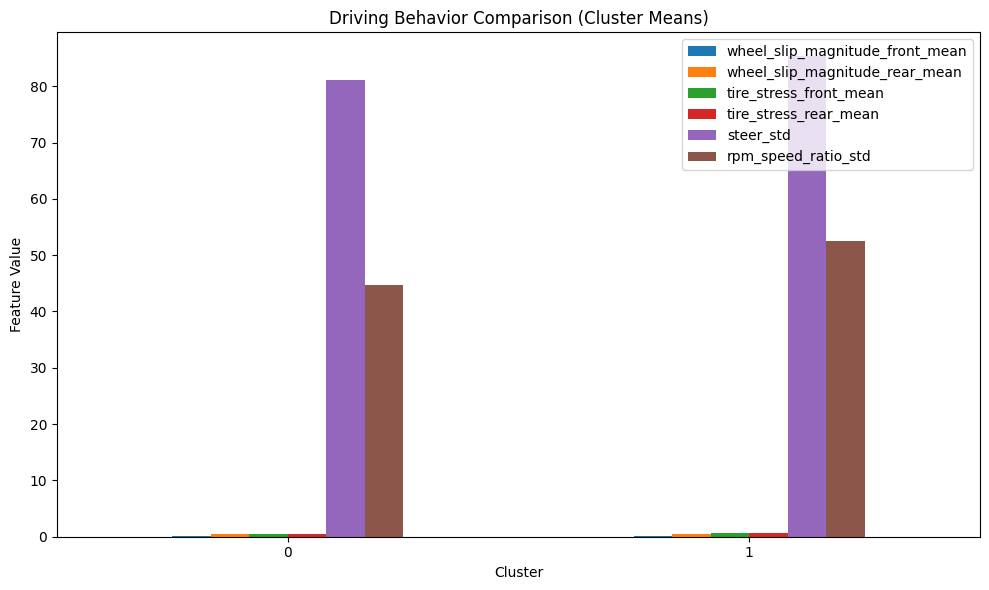

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

KEY_FEATURES = [
    "wheel_slip_magnitude_front_mean",
    "wheel_slip_magnitude_rear_mean",
    "tire_stress_front_mean",
    "tire_stress_rear_mean",
    "steer_std",
    "rpm_speed_ratio_std"
]

cluster_summary[KEY_FEATURES].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Driving Behavior Comparison (Cluster Means)")
plt.ylabel("Feature Value")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


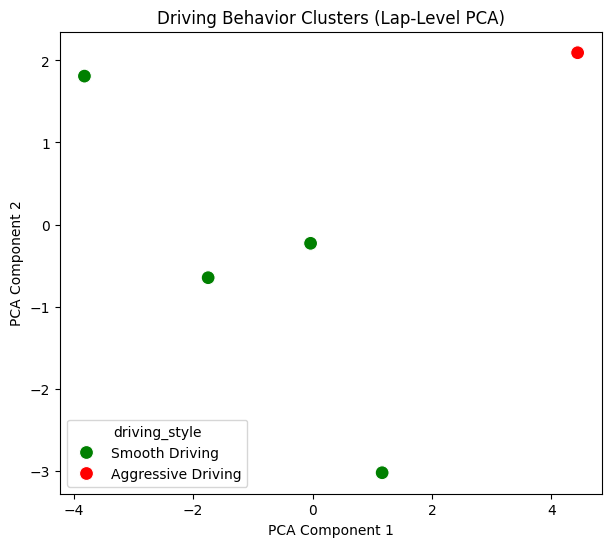

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=lap_features["driving_style"],
    palette=["green", "red"],
    s=100
)

plt.title("Driving Behavior Clusters (Lap-Level PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [14]:
os.makedirs("artifacts/driving_behavior", exist_ok=True)

joblib.dump(kmeans, "artifacts/driving_behavior/kmeans.pkl")
joblib.dump(scaler, "artifacts/driving_behavior/scaler.pkl")

print("Driving behavior clustering model saved.")

Driving behavior clustering model saved.


In [16]:
val = pd.read_csv("data/splits/val.csv")

# Load clustering artifacts
kmeans = joblib.load("artifacts/driving_behavior/kmeans.pkl")
scaler = joblib.load("artifacts/driving_behavior/scaler.pkl")

print(val.shape)
AGG_MAP = {
    "acceleration_magnitude": ["mean", "std"],
    "steer": ["mean", "std"],
    "yaw": ["std"],
    "wheel_slip_magnitude_front": ["mean", "max"],
    "wheel_slip_magnitude_rear": ["mean", "max"],
    "tire_stress_front": ["mean"],
    "tire_stress_rear": ["mean"],
    "rpm_speed_ratio": ["mean", "std"]
}

val_lap_features = (val.groupby("lap_number").agg(AGG_MAP))

val_lap_features.columns = ["_".join(col) for col in val_lap_features.columns]

print(val_lap_features.shape)
val_lap_features.head()
X_val_scaled = scaler.transform(val_lap_features)
val_clusters = kmeans.predict(X_val_scaled)
val_lap_features["cluster"] = val_clusters
CLUSTER_LABELS = {0: "Smooth Driving",1: "Aggressive Driving"}
val_lap_features["driving_style"] = (val_lap_features["cluster"].map(CLUSTER_LABELS))
val_lap_features[["cluster", "driving_style"]]
val_with_style = val.merge(val_lap_features[["driving_style"]].reset_index(),on="lap_number",how="left")

val_with_style[["lap_number", "driving_style"]].head()
print(val_lap_features["driving_style"].value_counts())

(14181, 21)
(5, 13)
driving_style
Smooth Driving        4
Aggressive Driving    1
Name: count, dtype: int64
